In [2]:
# 📦 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error



california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr = LinearRegression()
lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)
residuals = y_test - y_pred


1: Linearity

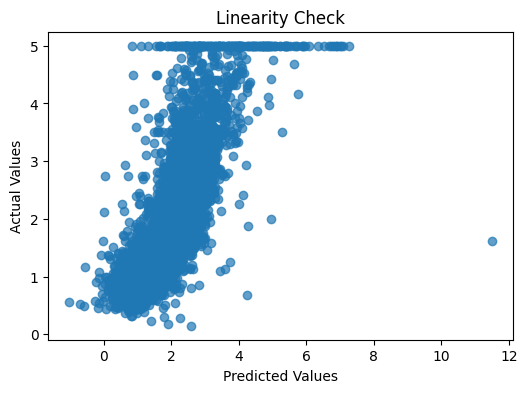

In [3]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, y_test, alpha=0.7)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Linearity Check")
plt.show()


2️⃣ Independence of Errors

We use the Durbin–Watson test.

👉 Values between 1.5 and 2.5 indicate independence.

In [4]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("Durbin–Watson Test Value:", dw)


Durbin–Watson Test Value: 2.040741738727077


3: Homoscedasticity

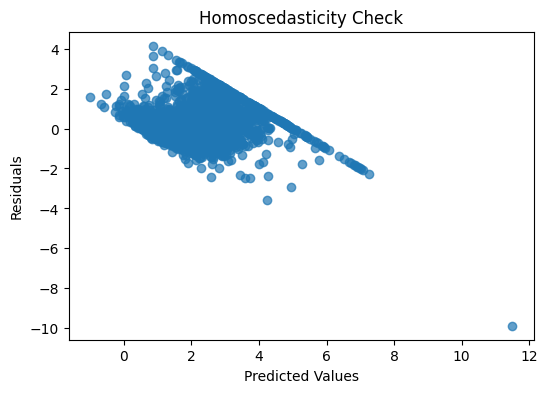

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Homoscedasticity Check")
plt.show()


4: Normality of Errors

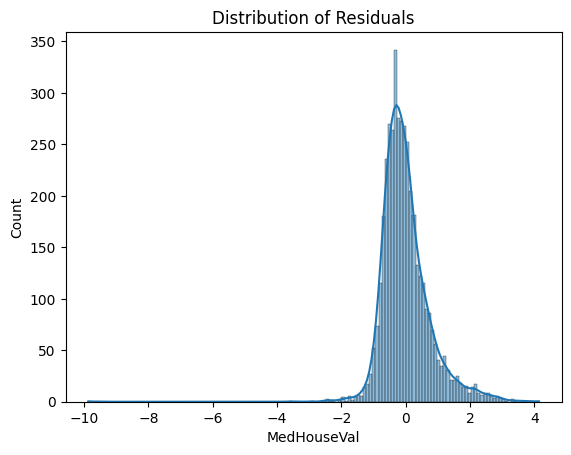

In [6]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

5: No Multicollinearity

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654
